In [2]:
import pandas as pd

# Load the dataset
data = pd.read_csv("payload_full.csv")

# Display the first 10 rows
print(data.head(10))

                    payload  length attack_type label
0            c/ caridad s/n      14        norm  norm
1              campello, el      12        norm  norm
2                     40184       5        norm  norm
3          1442431887503330      16        norm  norm
4                     nue37       5        norm  norm
5               nuda drudes      11        norm  norm
6            tufts3@joll.rs      14        norm  norm
7                 22997112x       9        norm  norm
8  c/ del ferrocarril, 152,      24        norm  norm
9        arenas de san juan      18        norm  norm


In [3]:
print("Number of rows:", len(data))
print("Number of columns:", len(data.columns))

Number of rows: 31067
Number of columns: 4


In [4]:
print(data.columns)

Index(['payload', 'length', 'attack_type', 'label'], dtype='object')


In [5]:
print(data["attack_type"].value_counts())

norm              19304
sqli              10852
xss                 532
path-traversal      290
cmdi                 89
Name: attack_type, dtype: int64


In [6]:
data = data[data["attack_type"].isin(["norm", "sqli"])]

In [7]:
print(data["attack_type"].value_counts())

norm    19304
sqli    10852
Name: attack_type, dtype: int64


In [8]:
print(data.isnull().sum())

payload        0
length         0
attack_type    0
label          0
dtype: int64


In [9]:
data = data.drop_duplicates(subset=["payload"])

In [10]:
print("Rows after removing duplicates:", len(data))

Rows after removing duplicates: 30156


In [11]:
X = data["payload"]

In [12]:
y = data["label"]

In [13]:
X = data["payload"]
y = data["label"]

print(X.head())
print(y.head())

0      c/ caridad s/n
1        campello, el
2               40184
3    1442431887503330
4               nue37
Name: payload, dtype: object
0    norm
1    norm
2    norm
3    norm
4    norm
Name: label, dtype: object


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 24124
Testing samples: 6032


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 5)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (24124, 264817)
Testing shape: (6032, 264817)


In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [19]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:20])

['norm' 'anom' 'norm' 'norm' 'norm' 'anom' 'norm' 'norm' 'anom' 'norm'
 'anom' 'norm' 'norm' 'anom' 'anom' 'norm' 'norm' 'norm' 'norm' 'anom']


In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9991710875331565


In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        anom       1.00      1.00      1.00      2171
        norm       1.00      1.00      1.00      3861

    accuracy                           1.00      6032
   macro avg       1.00      1.00      1.00      6032
weighted avg       1.00      1.00      1.00      6032



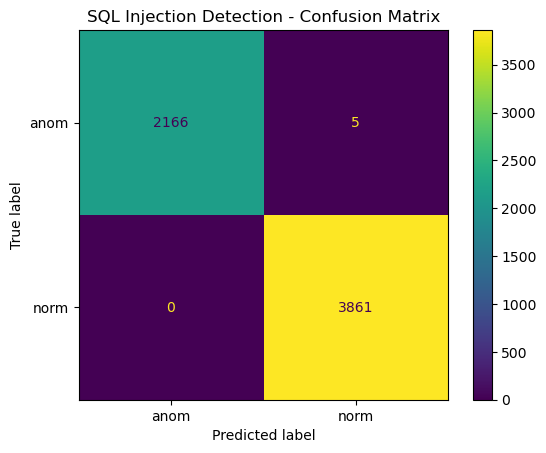

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("SQL Injection Detection - Confusion Matrix")
plt.show()

In [23]:
def detect_sqli(payload):
    payload_tfidf = vectorizer.transform([payload])
    prediction = model.predict(payload_tfidf)[0]
    return prediction

In [24]:
test_payloads = [
    "Koustav",
    "hello world",
    "12345",
    "' OR '1'='1",
    "admin'--",
    "' UNION SELECT username FROM users --"
]

for payload in test_payloads:
    result = detect_sqli(payload)
    print(payload, "=>", result)

Koustav => norm
hello world => norm
12345 => norm
' OR '1'='1 => anom
admin'-- => norm
' UNION SELECT username FROM users -- => anom
